## Navigo Neuron Reprogramming Screening

Direct cellular reprogramming can convert one somatic cell type into another by overexpressing key transcription factors (TFs). This tutorial uses Navigo's virtual perturbation framework to screen candidate TFs for their ability to reprogram cardiac fibroblasts to neurons, then validates the predictions against experimental reprogramming efficiency data.

**Steps:**
1. Run virtual perturbation for each TF combination
2. Evaluate predictions against ground-truth with ROC analysis
3. Visualise AUROC sensitivity across thresholds
4. Plot the ROC curve for the best setting
5. Rank single bHLH TFs by predicted reprogramming accuracy

In [1]:
import warnings, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score
from matplotlib.patches import Patch

import navigo, navigo.tl
from navigo import run_perturbation_inference, set_seed
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")

data_shared_dir = DATA_DIR / 'shared'
data_repro_dir  = DATA_DIR / 'reprogramming'

CHECKPOINT_PATH     = CHECKPOINT_DIR / 'reprogramming' / 'neural_reprogramming_checkpoint.pth'
DATA_PATH           = data_shared_dir / 'mouse_heart_fibroblasts.h5ad'
TARGET_LIST_PATH    = data_repro_dir / 'neuron_screen_targets.csv'
METRICS_PATH        = data_repro_dir / 'neuron_screen_metrics.csv'
GROUNDTRUTH_PATH    = data_repro_dir / 'neuron_screen_groundtruth.csv'
SINGLE_METRICS_PATH = data_repro_dir / 'neuron_screen_bhlh_metrics.csv'

case_root = OUTPUT_DIR / 'reprogramming_neuron_screening'
RERUN_DIR = case_root / '01_inference_csv'
EVAL_DIR  = case_root / '02_metrics_tables'
for d in [RERUN_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(0)

## Step 1: Run virtual reprogramming screen

Silence each candidate TF (or TF pair) and measure the predicted transcriptional shift toward a neuronal phenotype using Navigo's ODE flow.

In [3]:
target_lines = [ln.strip() for ln in TARGET_LIST_PATH.read_text().splitlines() if ln.strip()]
targets_used_path = RERUN_DIR / 'targets_used.csv'
targets_used_path.write_text('\n'.join(target_lines) + '\n')

run_perturbation_inference(
    data_path=DATA_PATH, checkpoint_path=CHECKPOINT_PATH,
    target_list_path=targets_used_path, output_dir=RERUN_DIR,
    fibro_cell_type='Fibroblasts', input_dim=7804, hidden_1=5012, hidden_2=5012,
    flow_num_steps=100, simulation_steps=10,
    knockout_scale=3.0, device=DEVICE, strict_target_presence=True,
)
print(f'Generated {len(list(RERUN_DIR.glob("*.csv")))} CSV files for {len(target_lines)} targets.')

Perturbation inference:   0%|                                                                                     | 0/192 [00:00<?, ?it/s]

Perturbation inference:   1%|▍                                                                            | 1/192 [00:01<03:32,  1.11s/it]

Perturbation inference:   1%|▊                                                                            | 2/192 [00:03<04:59,  1.58s/it]

Perturbation inference:   2%|█▏                                                                           | 3/192 [00:04<05:30,  1.75s/it]

Perturbation inference:   2%|█▌                                                                           | 4/192 [00:06<05:44,  1.83s/it]

...

Perturbation inference:  99%|██████████████████████████████████████████████████████████████████████████▏| 190/192 [05:34<00:02,  1.10s/it]

Perturbation inference:  99%|██████████████████████████████████████████████████████████████████████████▌| 191/192 [05:35<00:01,  1.08s/it]

Perturbation inference: 100%|███████████████████████████████████████████████████████████████████████████| 192/192 [05:36<00:00,  1.06s/it]

Perturbation inference: 100%|███████████████████████████████████████████████████████████████████████████| 192/192 [05:36<00:00,  1.75s/it]

Generated 193 CSV files for 192 targets.


## Step 2: Evaluate against experimental screen data

Sweep programming efficiency thresholds and minimum expression filters. At each setting, compute the overall AUROC, per-TF and per-target AUROCs, and Spearman correlation between AUROC and expression level.

In [4]:
result = navigo.tl.evaluate_reprogramming_screen(
    DATA_PATH, RERUN_DIR, METRICS_PATH, GROUNDTRUTH_PATH, EVAL_DIR,
    exclude_genes=['Pou3f4', 'Pou2f1', 'Pou2f3', 'Pou6f1'],
)
summary_df = result['summary']
summary_df.pivot(index='threshold', columns='min_expr', values='overall_auc').round(3)

min_expr,0.000,0.005,0.010,0.015,0.020
threshold,,,,,
0.0,0.451,0.378,0.432,0.432,0.460
0.2,0.548,0.481,0.562,0.562,0.627
0.4,0.626,0.593,0.649,0.649,0.627
0.6,0.660,0.569,0.649,0.649,0.627
0.8,0.658,0.669,0.764,0.764,0.790
1.0,0.653,0.669,0.764,0.764,0.790


## Step 3: AUROC sensitivity heatmap

Visualise how the overall AUROC varies across threshold and expression filter settings. Robust performance (AUROC > 0.7) across a range of settings indicates the screen is not sensitive to arbitrary cutoffs.

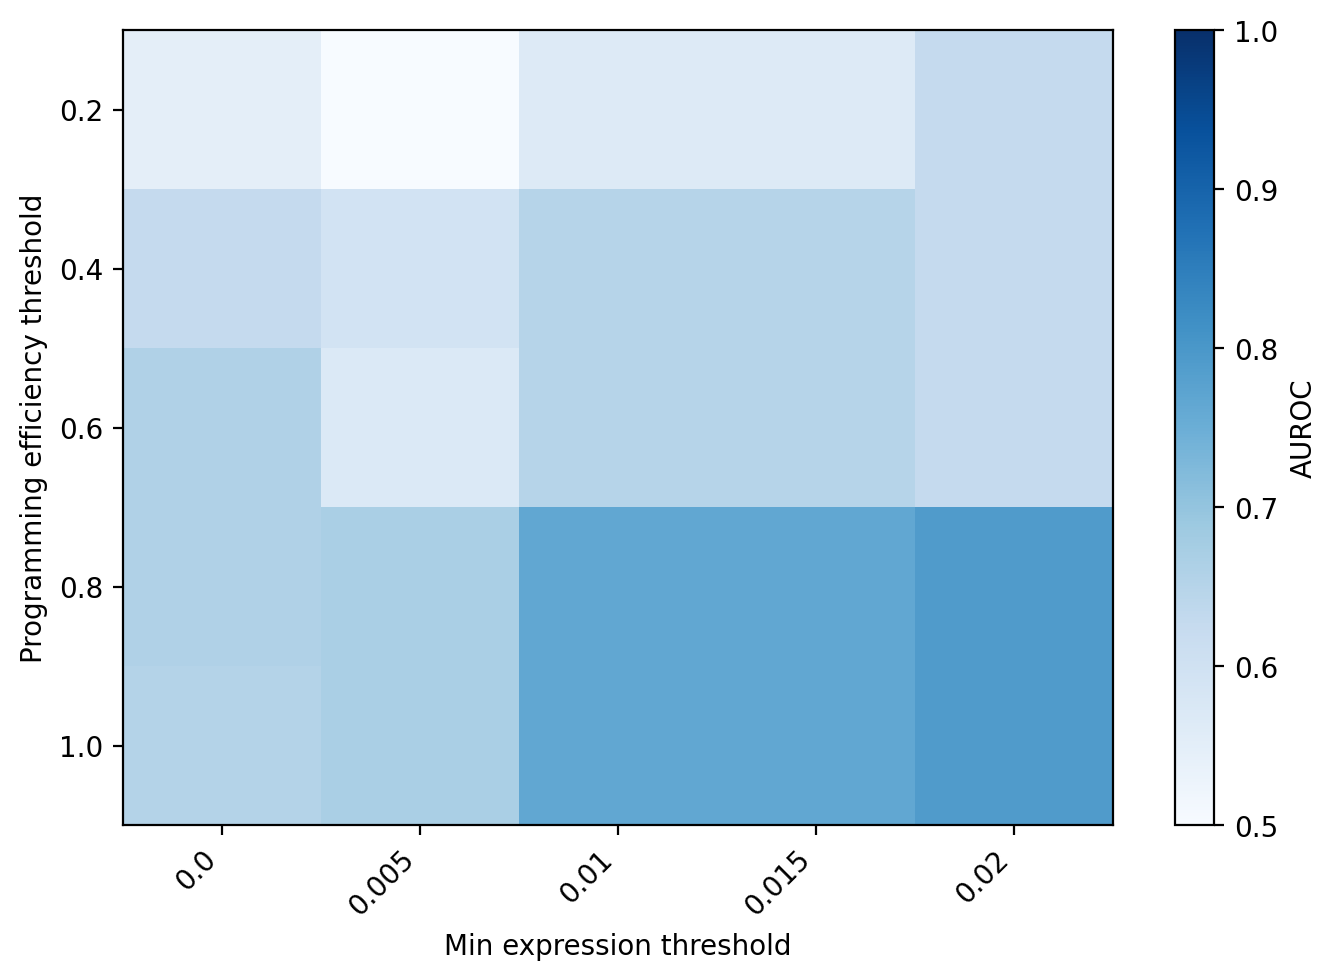

In [5]:
auroc_hm = result['auroc_heatmap']
auroc_hm.index = auroc_hm.index.astype(float)
plot_hm = auroc_hm[auroc_hm.index >= 0.2].sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(plot_hm.values, aspect='auto', cmap='Blues', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(plot_hm.columns)))
ax.set_xticklabels([str(c) for c in plot_hm.columns], rotation=45, ha='right')
ax.set_yticks(range(len(plot_hm.index)))
ax.set_yticklabels([f'{v:.1f}' for v in plot_hm.index])
ax.set_xlabel('Min expression threshold'); ax.set_ylabel('Programming efficiency threshold')
fig.colorbar(im, ax=ax, label='AUROC'); plt.tight_layout()

## Step 4: ROC curve for the best setting

Select the threshold/expression pair with the highest AUROC (among settings with sufficient TF and target counts) and plot the corresponding ROC curve.

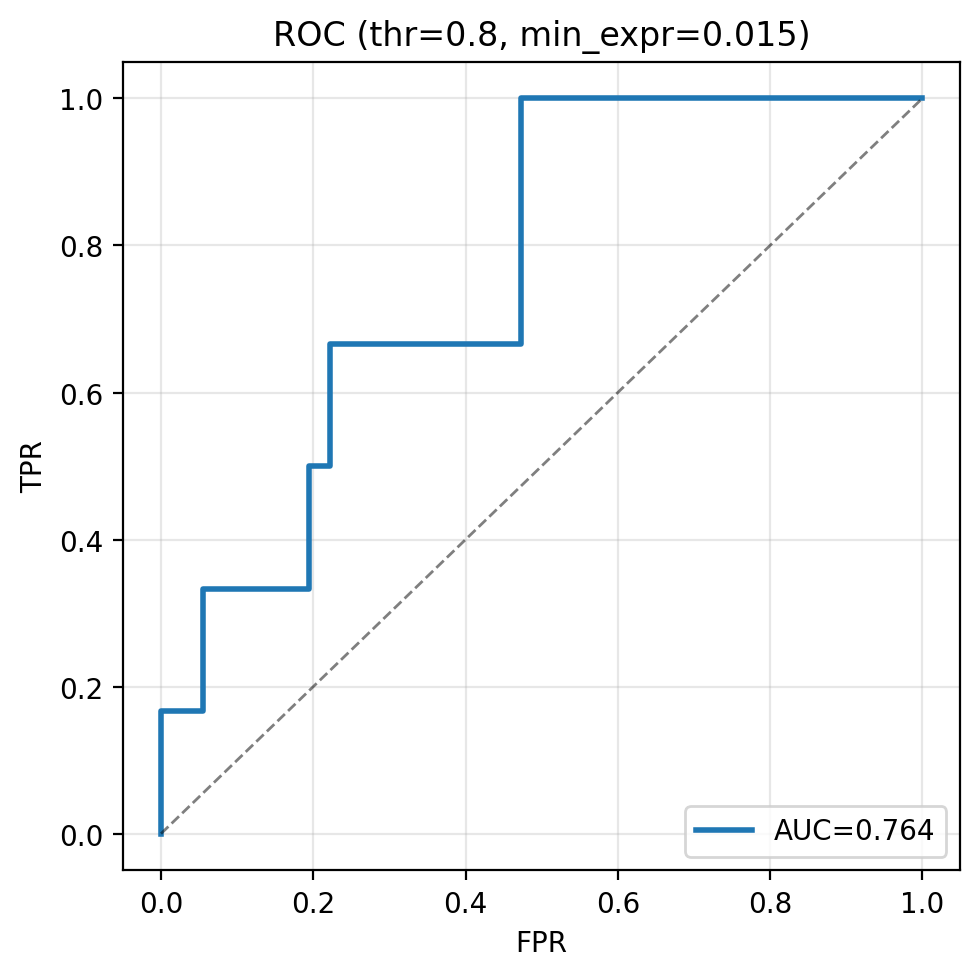

In [6]:
stable = summary_df[(summary_df['threshold'] >= 0.2) & (summary_df['tf_count'] >= 3)]
best = (stable if not stable.empty else summary_df[summary_df['threshold'] >= 0.2]).sort_values('overall_auc', ascending=False).iloc[0]
roc_key = (float(best.threshold), float(best.min_expr))
roc_df = result['roc_curves'][roc_key]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(roc_df['fpr'], roc_df['tpr'], lw=2, label=f"AUC={best.overall_auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC (thr={roc_key[0]}, min_expr={roc_key[1]})')
ax.legend(loc='lower right'); ax.grid(alpha=0.3); plt.tight_layout()

## Step 5: Top-10 single bHLH TF ranking

Using a separate single-TF screen, rank the top bHLH candidates by accuracy and compare to experimentally validated hits. Bold labels indicate TFs with experimental validation.

Single-screen AUROC: 0.663


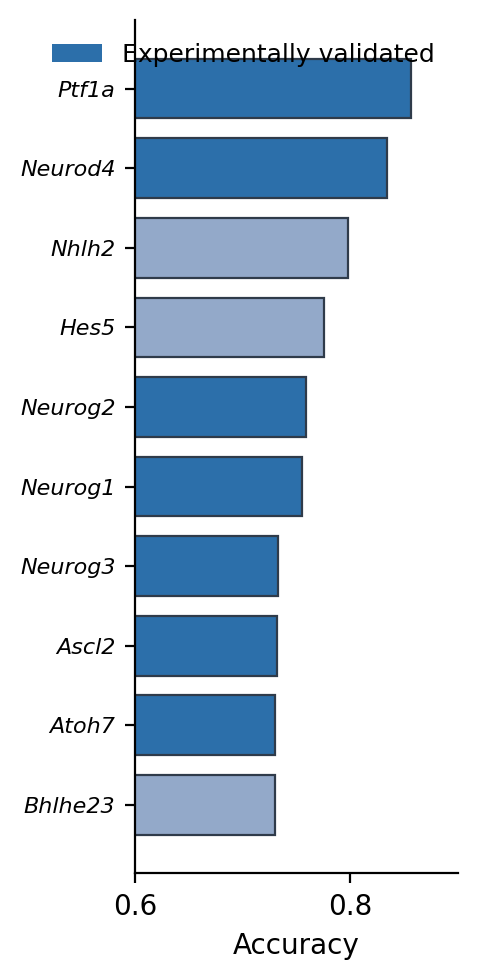

In [7]:
df_real = pd.read_csv(GROUNDTRUTH_PATH, index_col=0)
df_pred = pd.read_csv(SINGLE_METRICS_PATH)
valid_targets = set(df_real.columns[(df_real != 0).sum() > 0])
all_labels = [1 if tf in valid_targets else 0 for tf in df_pred['tf']]
single_auroc = float(roc_auc_score(all_labels, df_pred['avg_accuracy']))
df_top10 = df_pred.head(10).copy(); df_top10['label'] = all_labels[:10]

fig, ax = plt.subplots(figsize=(2.6, 5.0))
colors = ['#2c6faa' if v == 1 else '#93a9c9' for v in df_top10['label']]
ax.barh(range(len(df_top10)), df_top10['avg_accuracy'], color=colors, edgecolor='#2f3b4a', lw=0.8, height=0.75)
ax.set_yticks(range(len(df_top10))); ax.set_yticklabels(df_top10['tf'], fontstyle='italic', fontsize=8)
ax.invert_yaxis(); ax.set_xlim(0.6, 0.9); ax.set_xlabel('Accuracy')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(handles=[Patch(facecolor='#2c6faa', label='Experimentally validated')], frameon=False, fontsize=9)
plt.tight_layout()
print(f'Single-screen AUROC: {single_auroc:.3f}')